# 单纯形法（Simplex Method）

## 单纯形法预备知识

### 线性规划的标准型中的行满秩假设

回顾线性规划的的标准型：

$$
\begin{aligned}
\min \quad & c^T x \\
\text{s.t.} \quad & Ax = b \\
& x \geq 0
\end{aligned}
$$

$A$ 的行向量之间线性独立 $A$ 是秩为 $m$ 的行满秩矩阵。
如果不满足，那么：

- 可能存在冗余的约束（此时可以移除对应的冗余约束）
- 可能约束之间互斥（此时没有可行解）

### 极值点

设 $P \subset \mathbb{R}^n$ 为凸集。若点 $x^* \in P$ 满足：

$$
x^* = \lambda x^{(1)} + (1-\lambda)x^{(2)}, \quad \lambda \in (0,1), \quad x^{(1)},x^{(2)} \in P
$$

则必有：

$$
x^{(1)} = x^{(2)} = x^*,
$$

则称 $x^*$ 为集合 $P$ 的一个极值点。

### 基本解

$\mathbf{x}$ 是问题的基本解，当且仅当：

1. $A\mathbf{x} = \mathbf{b}$
2. 存在一组索引 $\mathcal{B} = \{B(1), B(2), \ldots, B(m)\}$，使得 $A_{\mathcal{B}}$ 线性独立，并且对于所有 $i \notin \mathcal{B}$，都有 $x_i = 0$。

#### 关于基本解的问题

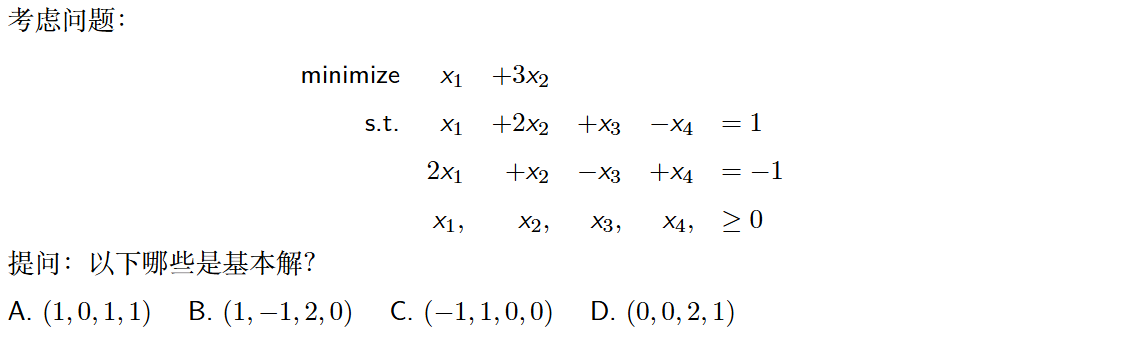

对于 $A \in \mathbb{R}^{m \times n}$，满足行满秩假设，基本解中非零元的个数最多为 $m$ 个，故排除 A 与 B。对于选项 C 与 D，由于，$(A_1, A_2)$ 线性无关， $(A_3, A_4)$ 线性相关，故C正确，D错误。

对于一个线性规划问题，需要先将其转化为标准型之后，新增了很多变量约束($x \geq 0$)，便于寻找基本解。

#### 定义

$$
A_B = \left[A_{B(1)} \quad A_{B(2)} \quad \ldots \quad A_{B(m)}\right], \quad \mathbf{x}_B = \begin{bmatrix} x_{B(1)} \\ x_{B(2)} \\ \vdots \\ x_{B(m)} \end{bmatrix}
$$

由于 $A_{B(1)}, A_{B(2)}, \ldots, A_{B(m)}$ 线性独立，所以 $A_B$ 可逆，且 $\mathbf{x}_B = A_B^{-1}\mathbf{b}$

对于这一基本解，称：

- $\mathcal{B} = \{B(1), B(2), \ldots, B(m)\}$ 为一组基
- $A_{B(1)}, A_{B(2)}, \ldots, A_{B(m)}$ 为基向量
- $A_B$ 为基矩阵
- $x_{B(1)}, x_{B(2)}, \ldots, x_{B(m)}$ 为基变量
- 类似地，$A$ 中其余的列向量为非基向量，$x$ 中其余的变量为非基变量

对于含 $m$ 个约束的基本解中非零元素：

- 不超过 $m$ 个
- 可以是 $0$ 至 $m$ 中任意一种，但通常为 $m$ 个

对于含 $m$ 个约束和 $n$ 个变量的线性规划问题，基本解最多有 $C_n^m$ 个。因此对于约束数目有限的问题，基本解也只可能是有限个。

### 基本可行解

对于基本解 $\mathbf{x}$，如果它满足非负约束 $\mathbf{x} \geq 0$，则称其为基本可行解。

- 首先找到一个基本解 $\mathbf{x}$
- 检查 $\mathbf{x} \geq 0$ 是否成立

对于标准型中的多面体 $\{\mathbf{x} \mid A\mathbf{x} = \mathbf{b}, \mathbf{x} \geq 0\}$ 及多面体上的点 $\mathbf{x}$，以下表述相互等价：

1. $\mathbf{x}$ 是极值点
2. $\mathbf{x}$ 是基本可行解

#### 证明

1. 证明：

$$x \text{是极值点} \rightarrow \text{它是基本可行解}$$

反证法：

假设 $\mathbf{x}$ 不是基本可行解。

定义 $\mathcal{B} = \{i | x_i > 0\} = \{B(1), B(2), \ldots, B(k)\}$，若 $\mathbf{x}$ 不是基本可行解，则

$$
\exist \mathbf{\alpha} = (\alpha_1, \alpha_2, \ldots, \alpha_k) > 0, \quad \mathbf{\alpha}^TA_{\mathcal{B}} = 0
$$

因此，存在某个 $\epsilon > 0$，使得如下构造的 $\bar{\mathbf{x}}$ 与 $\widetilde{\mathbf{x}}$ 可行：

$$
\bar{x_i} = \left\{ \begin{array}{ll} x_i + \epsilon \alpha_i \quad&  i \in \mathcal{B} \\ x_i   \quad &  i \notin \mathcal{B} \end{array} \right.
$$

$$
\widetilde{x_i} = \left\{ \begin{array}{ll} x_i - \epsilon \alpha_i \quad &  i \in \mathcal{B} \\ x_i   \quad &  i \notin \mathcal{B} \end{array} \right.
$$

此时：

$$
A \bar{\mathbf{x}} = A \widetilde{\mathbf{x}} = A\mathbf{x} = \mathbf{b}
$$

故：

$$
\mathbf{x} = \frac{1}{2} \bar{\mathbf{x}} + \frac{1}{2} \widetilde{\mathbf{x}}
$$

这与 $\mathbf{x}$ 是极值点矛盾。


2. 证明：

$$x \text{是基本可行解} \rightarrow \text{它是极值点}$$

反证法：

假设 $\mathbf{x}$ 不是极值点，则存在 $\mathbf{y} \neq \mathbf{z}$，使得 $\mathbf{x} = \lambda \mathbf{y} + (1-\lambda) \mathbf{z}$，其中 $\lambda \in (0,1)$。

因为 $\mathbf{x}_{\mathcal{N}} = 0, \lambda > 0$，所以 $\mathbf{y}_{\mathcal{N}} = \mathbf{z}_{\mathcal{N}} = 0$。由于 $\mathbf{x}_{\mathcal{b}} = A_{\mathcal{B}}^{-1} \mathcal{b}$ 存在且唯一，所以 $\mathbf{y}_{\mathcal{b}} = \mathbf{z}_{\mathcal{b}} = \mathbf{x}_{\mathcal{b}}$。因此不存在不同于 $\mathbf{x}$ 的 $\mathbf{y}$ 和 $\mathbf{z}$，与假设矛盾

$\mathcal{B} \neq \emptyset$

### 线性规划基本定理

于一个问题，矩阵 $A$ 为行满秩矩阵、秩为 $m$，此时

1. 如果存在可行解，那么也存在基本可行解；
2. 如果存在最优解，那么也存在一个最优解是基本可行解。

1. 证明：

假设存在一个可行解 $\mathbf{x}$。定义集合 $B(\mathbf{x})$ 及其元素数目 $k(\mathbf{x})$。

关键点：如果 $\mathbf{x}$ 不是基本解，则存在 $\mathbf{y}$ 为可行解使得 $k(\mathbf{y}) < k(\mathbf{x})$。如此反复，最终得到一个基本解。

由于 $\mathbf{x}$ 不是基本解，故 $\{A_i\}_{i \in \mathcal{B}(\mathbf{x})}$ 线性相关，对于 $i \in \mathcal{B}(\mathbf{x})$：

$$
\exist \mathbf{\alpha} \text{不全为0} \quad \text{使得} \quad \mathbf{\alpha}^TA_{\mathcal{B}(\mathbf{x})} = 0
$$

令 $\mathbf{y} = \mathbf{x} + \epsilon \mathbf{\alpha}$，其中 $\epsilon > 0$ 保证 $\mathbf{y}$ 可行。

2. 证明

关键点：如果 $\mathbf{x}$ 不是基本解，那么存在 $\mathbf{y}$ 为最优解使得 $k(\mathbf{y})$ < $k(\mathbf{x})$。如此反复，最终得到一个基本解。

按上述定义 $\mathbf{\alpha}$ 若 $c^T\mathbf{\alpha} \neq 0$，则存在一个较小的正数 $\epsilon > 0$ 使得 $\mathbf{y} = \mathbf{x} + \epsilon \mathbf{\alpha}$ 或者 $\mathbf{y} = \mathbf{x} - \epsilon \mathbf{\alpha}$ 优于 $\mathbf{x}$。故 $\mathbf{c}^T \mathbf{\alpha} = 0$。

由于 $\mathbf{c}^T \mathbf{\alpha} = 0$，故可以构造 $\mathbf{y} = \mathbf{x} - \epsilon \mathbf{\alpha}$ 使得 $\mathbf{y}$ 为最优解。同样地，

$$
\exist \epsilon > 0, \quad\text{使得} k(\mathbf{y}) < k(\mathbf{x})
$$

## 单纯形法


1. 找到初始可行解
2. 沿着提升目标值的棱边移动
3. 找到最优解

### 规范型与最优性检验

几张有启发性的ppt：

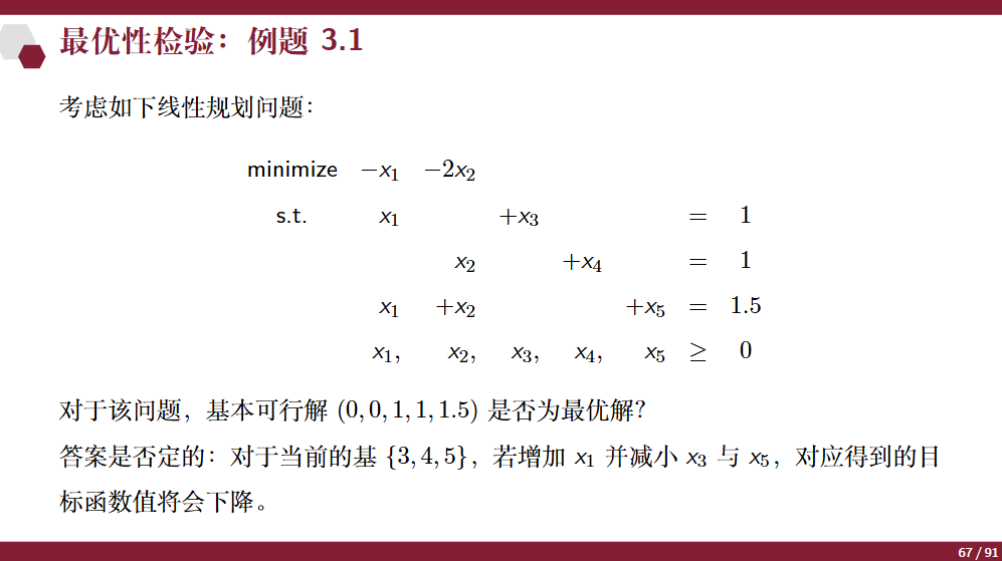

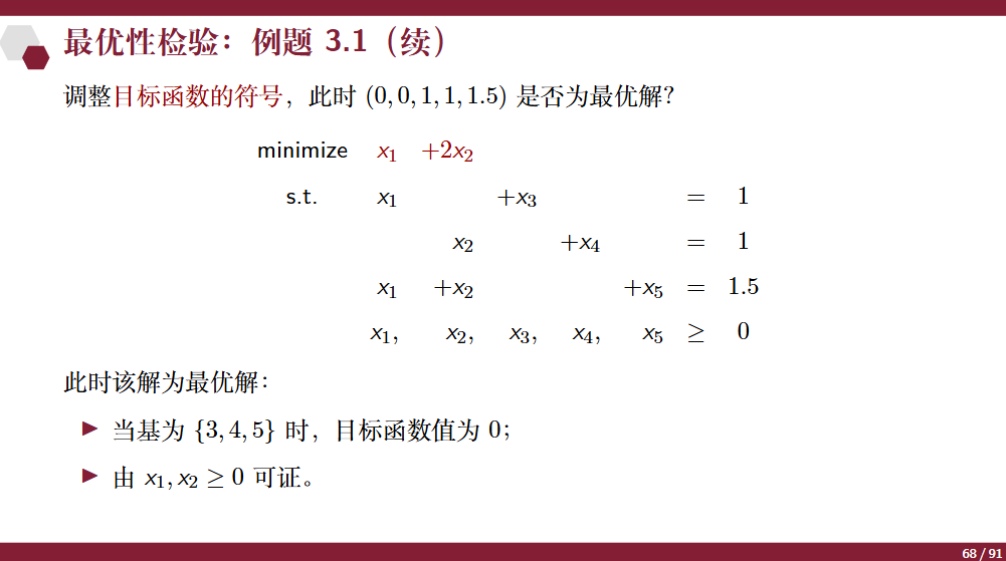

#### 规范型

标准型若是关于某组基的规范型，则：

- 对于目标函数，基变量部分的系数为零（即目标函数只与非基变量相关）；
- 对于约束矩阵，基矩阵（或适当调整基向量顺序后）可以组成单位矩阵 。

$$
\begin{aligned}
\min \quad & c_{\mathcal{B}}^T \mathbf{x}_{\mathcal{B}} + c_{\mathcal{N}}^T \mathbf{x}_{\mathcal{N}} \\
\text{s.t.} \quad & A \mathbf{x} = \begin{bmatrix} A_{\mathcal{B}} & A_{\mathcal{N}} \end{bmatrix} \begin{bmatrix} \mathbf{x}_{\mathcal{B}} \\ \mathbf{x}_{\mathcal{N}} \end{bmatrix} = \begin{bmatrix} \mathbf{b}_{\mathcal{B}} \\ \mathbf{b}_{\mathcal{N}} \end{bmatrix} \\ 
\quad & \mathbf{x} \geq 0
\end{aligned}
$$

其中 $A_{\mathcal{B}}$ 是基矩阵，可以通过适当调整基向量顺序后组成单位矩阵。$c_{\mathcal{B}} = 0$

等式约束 $A \mathbf{x} = \mathbf{b}$ 可以转化为 $A_{\mathcal{B}}^{-1} A \mathbf{x} = A_{\mathcal{B}}^{-1} \mathbf{b}$，即 $x_{\mathbf{B}} + A_{\mathcal{B}}^{-1} A_{\mathcal{N}} \mathbf{x}_{\mathcal{N}} = A_{\mathcal{B}}^{-1} \mathbf{b}$，于是：

$$
x_{\mathbf{B}} = A_{\mathcal{B}}^{-1} \mathbf{b} - A_{\mathcal{B}}^{-1} A_{\mathcal{N}} \mathbf{x}_{\mathcal{N}}
$$

于是，目标函数变为：

$$
\mathbf{c}_{\mathcal{B}}^T A_{\mathcal{B}}^{-1} \mathbf{b} + (\mathbf{c}_{\mathcal{N}}^T - \mathbf{c}_{\mathcal{B}}^T A_{\mathcal{B}}^{-1} A_{\mathcal{N}}) \mathbf{x}_{\mathcal{N}}
$$

以上两个转换可以得到基为 $\mathcal{B}$ 下基本可行解的规范型。

忽略目标函数的常数项 $\mathbf{c}_{\mathcal{B}}^T A_{\mathcal{B}}^{-1} \mathbf{b}$，可以写出如下规范型：

$$
\begin{aligned}
\min \quad & \bar{\mathbf{c}}^T \mathbf{x} \\
\text{s.t.} \quad & \bar{A} \mathbf{x} = \bar{\mathbf{b}} \\ 
\quad & \mathbf{x} \geq 0
\end{aligned}
$$

其中：

- $\bar{A} = A_{\mathcal{B}}^{-1} A$，$\bar{\mathbf{b}} = A_{\mathcal{B}}^{-1} \mathbf{b}$
- $\bar{\mathbf{c}} = \mathbf{c}^T - \mathbf{c}_{\mathcal{B}}^T A_{\mathcal{B}}^{-1} A_{\mathcal{N}}$

于基为 $\mathcal{B}$ 的基本可行解 x，若 $\bar{c} \geq 0$ ，那么 $\mathbf{x}$ 为最优解、$\mathcal{B}$ 为最优基。

#### 单纯型表

在单纯形法求解时，通常构建一个单纯形表刻画规范型的转换：

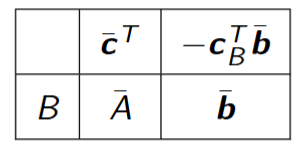

### 基变量转换

流程：

1. 从非基变量中选择 $x_e$ 满足 $\bar{c}_e<0$
2. 若第 $e$ 列 $A_e \leq 0$，则该问题无界
3. 否则选取如下的 $\theta^*$：

$$
\theta^*=\min_i \left\{ {\frac{\bar{b}_i}{\bar{A}_ie}}, \quad  \bar{A}_ie > 0\right\}
$$

$\theta^*$ 表示在解可行的条件下能够增大的最大值，此时恰好有某个（或多个）基变量变为零。

假设第 $i$ 行的基变量 $x_{\mathcal{B}(i)}$ 变为 $0$，即满足：

$$
\left\{
    \begin{aligned}
    x_{\mathcal{B}(i)} = \bar{b}_i-\bar{A}_{ie}\theta^*=0 \quad& \\
    x_{\mathcal{B}(i')} = \bar{b}_{i'}-\bar{A}_{i'e}\theta^*>0 \quad& \forall i' \neq i
    \end{aligned}
\right.
$$

令 $o=\mathcal{B}(i)$，此时称 $x_e$ 为入基变量， $x_o$ 为出基变量.

若不止一个基变量为 $0$，理论上可以将任意一个作为出基变量

更新后的基本可行解是退化的，因为其部分基变量为 $0$

### 单纯形法算法框架

假设初始问题为规范型：对应基为 $\mathcal{B}$，基本可行解为 $\mathbf{x}$。

1. 首先，计算 $\bar{c}$，其中：

$$
\bar{c} = \mathbf{c}^T_{\mathcal{N}} - \mathbf{c}^T_{\mathcal{B}} A_{\mathcal{B}}^{-1} A_{\mathcal{N}}
$$

2. 如果 $\bar{c} \geq 0$，则 $\mathbf{x}$ 为最优解，算法结束

- 如果 $\bar{A}_{e} \leq 0$，则 该问题无界，最优值为 $-\infty$
- 否则将 $x_e$ 选为入基变量，计算：

$$
\theta^* = \min_i \left\{ \frac{\bar{b}_i}{\bar{A}_{ie}} \mid \bar{A}_{ie} > 0 \right\}
$$

得到出基变量 $x_o$。

3. 更新当前的基 B，并将问题转化为新的规范型。

4. 重复上述的流程。

### 寻找基本可行解的相邻基本可行解

希望找到一个相邻的基本可行解：

邻近点同样为基本可行解，但与当前解相差一个基变量; 选一个非基变量 $x_j$ 作为入基
变量; 也就是基于当前的基本可行解增加 $x_j$ 的值。

考虑将基本可行解 $\mathbf{x}$ 平移到 $\mathbf{x} + \theta \mathbf{d}$，其中：

1. $d_j = 1$
2. 对于其他位置 $j'$，$d_{j'} = 0$

对于 $\mathbf{d}$ 要求，平移后的 $\mathbf{x} + \theta \mathbf{d}$ 仍为可行解，即满足：
$$
A(\mathbf{x} + \theta \mathbf{d}) = \mathbf{b}
$$

从而得到：

$$
A\mathbf{d} = 0
$$

将 $\mathbf{d}$ 改写为 $\begin{bmatrix} \mathbf{d}_{\mathcal{B}} & \mathbf{d}_{\mathcal{N}}  \end{bmatrix}$，对于 $\mathbf{d}_{\mathcal{N}}$，其中的 $d_j=1$，其余都等于 $0$.

此时有：

$$
A_{\mathcal{B}} \mathbf{d}_{\mathcal{B}} + A_{j} = 0
$$

所以有：

$$
\mathbf{d}_{\mathcal{B}} = -A_{\mathcal{B}}^{-1} A_{j}
$$

因此，$\mathbf{d}$ 的取值是唯一确定的，称这样的 $\mathbf{d}$ 为第 $j$ 个基方向。

### 目标值的变化

对于原始目标函数，目标函数的变化值为：$\theta \mathbf{c}^T\mathbf{d}$

代入 $\mathbf{d}$ 的表达式有：

$$
\mathbf{c}^T\mathbf{d} = \mathbf{c}_{\mathcal{B}}^T \mathbf{d}_{\mathcal{B}} + \mathbf{c}_{\mathcal{N}}^T \mathbf{d}_{\mathcal{N}} = -\mathbf{c}_{\mathcal{B}}^T A_{\mathcal{B}}^{-1} A_{j} + \mathbf{c}_j = \bar{c}_j
$$

### 检验数

$$
\bar{c}_j = c_j - \mathbf{c}_{\mathcal{B}}^T A_{\mathcal{B}}^{-1} A_j
$$

作为单纯形法中较为重要的概念，它反映了当基作出调整时，目标函数的单位变化量。

- 第一项反映了每增加一单位 $x_j$ 所变化的成本。
- 第二项是为了满足约束 $A \mathbf{x} = \mathbf{b}$，补偿基变量调整所带来的成本。

给定当前的基及入基变量 $x_j$ ，检验数可以很容易地计算：

- 当检验数为正，说明加入 $j$ 到当前的基将增加目标函数值；
- 当检验数为负，说明加入 $j$ 到当前的基将减小目标函数值。

对于基变量 $\mathbf{x}_{\mathcal{B}(i)}$，检验数 $\bar{c}_{\mathcal{B}(i)}$ 是 $0$.


$$
\bar{c}_{\mathcal{B}(i)} = c_{\mathcal{B}(i)} - \mathbf{c}_{\mathcal{B}}^T A_{\mathcal{B}}^{-1} A_{\mathcal{B}(i)} = c_{\mathcal{B}(i)} - \mathbf{c}_{\mathcal{B}}^T \mathbf{e}_i = 0
$$

其中 $\mathbf{e}_i$ 表示仅第 $i$ 个分量为 1，其余分量为 0 的向量。

### 迭代终止条件

于一个基为 $\mathcal{B} = \{\mathcal{B}(1), . . . , \mathcal{B}(m)\} $ 的基本可行解$x$，令 $\bar{c}$ 为各变量对应检验数所构成的向量。若 $\bar{c} \geq 0$，则 $x$ 为最优解。

#### 证明

假设对于基本可行解 $\mathbf{x}$，所有的检验数 $\bar{\mathbf{c}} \geq 0$。

考虑仍以一个可行解 $\mathbf{y}$，定义 $\mathbf{d} = \mathbf{y} - \mathbf{x}$。

由于 $\mathbf{x}$ 与 $\mathbf{y}$ 都是可行解，所以 $\mathbf{d}$ 满足 $A \mathbf{d} = \mathbf{0}$。

$$
A_{\mathcal{B}} \mathbf{d}_{\mathcal{B}} + A_{\mathcal{N}} \mathbf{d}_{\mathcal{N}} = 0
$$

因此：

$$
\mathbf{d}_{\mathcal{B}} = -A_{\mathcal{B}}^{-1} A_{\mathcal{N}} \mathbf{d}_{\mathcal{N}}
$$

分析目标函数值变化：

$$
\mathbf{c}^T \mathbf{d} = \mathbf{c}_{\mathcal{B}}^T \mathbf{d}_{\mathcal{B}} + \mathbf{c}_{\mathcal{N}}^T \mathbf{d}_{\mathcal{N}} = -\mathbf{c}_{\mathcal{B}}^T A_{\mathcal{B}}^{-1} A_{\mathcal{N}} \mathbf{d}_{\mathcal{N}} + \mathbf{c}_{\mathcal{N}}^T \mathbf{d}_{\mathcal{N}} = \bar{\mathbf{c}}^T \mathbf{d}_{\mathcal{N}} \geq 0
$$

故：

$$
\mathbf{c}^T \mathbf{y} = \mathbf{c}^T \mathbf{x} + \mathbf{c}^T \mathbf{d} \geq \mathbf{c}^T \mathbf{x}
$$

因此，$\mathbf{x}$ 是最优解。

### 基的变换

对于 $\bar{c}_j < 0$，将 $d$ 选择第 $j$ 个基方向。沿着这个方向更新会减小目标值，但更新的步长 $\theta$ 应该选取多少？

- 需要保证 $\mathbf{x} + \theta \mathbf{d} \geq 0$；
- 需要 $\theta$ 尽可能的大；
$$
\theta^* = \max \{\theta \geq 0 \mid \mathbf{x} + \theta \mathbf{d} \geq 0\}
$$

对于 $\theta^*$ 有两种情形：

- $\mathbf{d} \geq 0$，那么 $\theta^* = \infty$，此时问题无界。

- 如果对于某些 $i$ 有 $d_i < 0$，则 $\theta^* = \min_i \left\{ \frac{-x_i}{d_i} \mid d_i < 0 \right\}$

- 对于任意 $i \in \mathcal{N}$ 满足 $d_i \geq 0$，有：

$$\theta^* = \min_{\{i\in \mathcal{B} | d_i < 0\}} \left\{ \frac{-x_i}{d_i} \mid d_i < 0 \right\}$$



在 $\theta^*$ 有限的情况下，得到另一个可行解：

$$
\mathbf{y} = \mathbf{x} + \theta^* \mathbf{d}
$$

假设 $\mathcal{B}(\ell) \in \{\mathcal{B}(1), ..., \mathcal{B}(m)\}$ 对应于 $\theta^* = -\frac{x_{\mathcal{B}(\ell)}}{d_{\mathcal{B}(\ell)}}$ （可能存在多个满足 $\theta^*$ 的 $\mathcal{B}(\ell)$，后续对其进行讨论），那么则有：

$$
y_{\mathcal{B}(\ell)} = x_{\mathcal{B}(\ell)} + \theta^* d_{\mathcal{B}(\ell)} = 0
$$

因此，原先的基变量 $x_{\mathcal{B}(\ell)}$ 变为 0，而原先的非基变量 $x_j$ 变为正数。也就是说基转换为：

$$
\mathcal{B}(1), ..., \mathcal{B}(\ell-1), j, \mathcal{B}(\ell+1), ..., \mathcal{B}(m)
$$

## 人工变量法与退化形

在大多情形下，在单纯形法的迭代中目标函数值都会严格下降。

- 如果严格下降都能成立，由于基本可行解的数量有限，那么单纯形法一定能在有限次数的迭代后停止。
- 然而，在迭代过程中存在目标函数值不变的情况。如果处理不当，可能会引起问题。
- 这也就是单纯形法中的退化问题，之后课程将对这种情况进行分析。

在转换标准型的过程中，如果是对每个约束都加上一个松弛变量，那么很容易找到初始基本可行解，因为，对于每个约束 $a_i^T x \leq b_i$，引入一个松弛变量 $s_i$，使得约束变为 $a_i^T x + s_i = b_i$，其中 $s_i \geq 0$。此时，初始基本可行解可以选择 $x = 0$ 和 $s = b$，满足所有约束条件，并且是一个基本可行解。

然而，从一个标准型中找到初始基本可行解通常并不容易

- 一种方法是检查不同的基 $\mathcal{B}$，并判断是否满足 $A_{\mathcal{B}}^{-1} b \geq 0$。
- 在计算的复杂度上（后续将详细讨论），寻找一个初始基本可行解与求得最优解一样困难

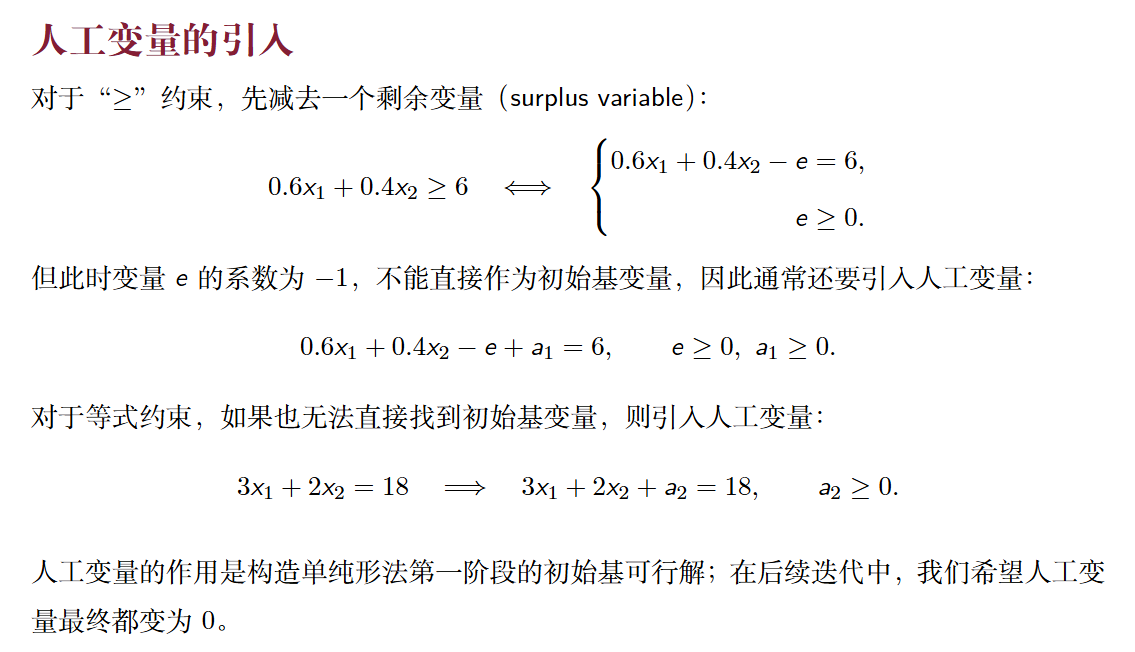
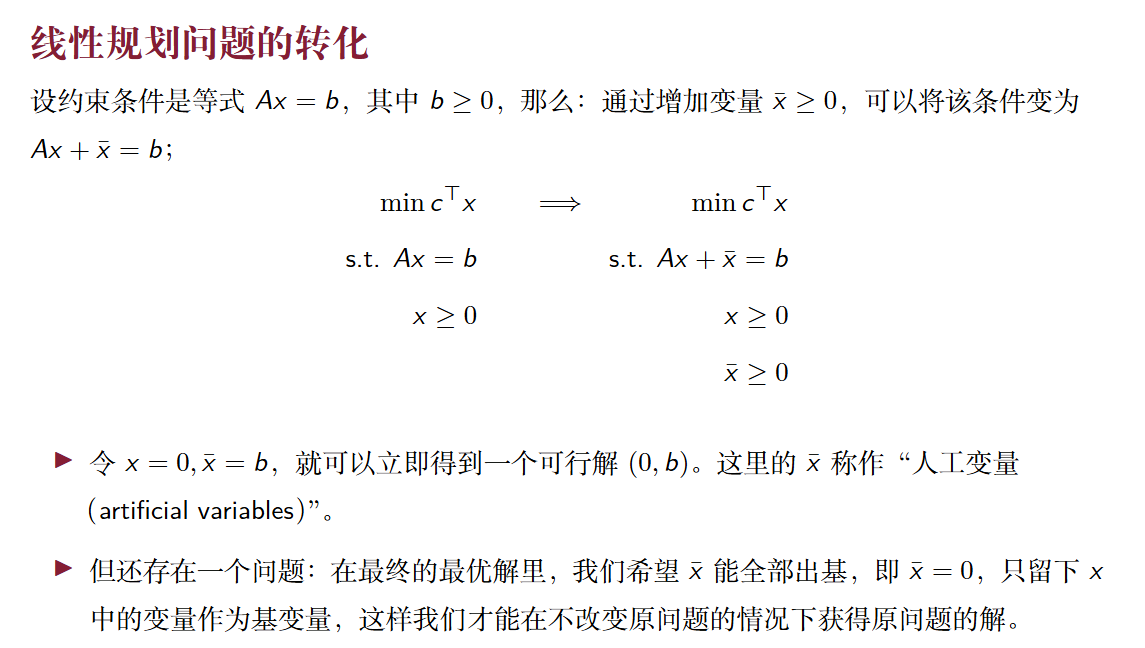

### 大 M 法

一种不需要专门寻找初始基本可行解、以求解线性规划的方法。考虑如下的辅助问题：

$$
\begin{aligned}
\min \quad & c^T x + M \sum_{i=1}^m \bar{x}_i \\
\text{s.t.} \quad & A\mathbf{x} + \bar{\mathbf{x}} = b \\
& \mathbf{x} \geq 0, \quad \bar{\mathbf{x}} \geq 0
\end{aligned}
$$

同样假设 $\mathbf{b} \geq 0$，该问题存在一个初始基本可行解 $\bar{\mathbf{x}} = \mathbf{b} \geq 0$，因此同样可以使用单纯形法求解。与一般线性规划不同，该辅助问题引入一个足够大的正数 M。

如果最优解中人工变量 $\bar{x}_i = 0$，则最后一张表中 BFS 是原问题的最优解。否则原问题无解。

#### 大 M 法性质

- 如果大 $M$ 法求解得到的 $(x^*, \bar{x}^*)$ 之中 $\bar{x}^* = 0$，那么 $x^*$ 是原问题最优解；
- 当 $M$ 充分大时，大 $M$ 法求解得到的 $(x^*, \bar{x}^*)$ 之中 $\sum_{i=1}^m \bar{x}_i^* > 0$，那么原问题无可行解；
- 当 $M$ 充分大时，大 $M$ 法没有有限的最优解，则原问题要么无可行解，要么没有有限的最优解。

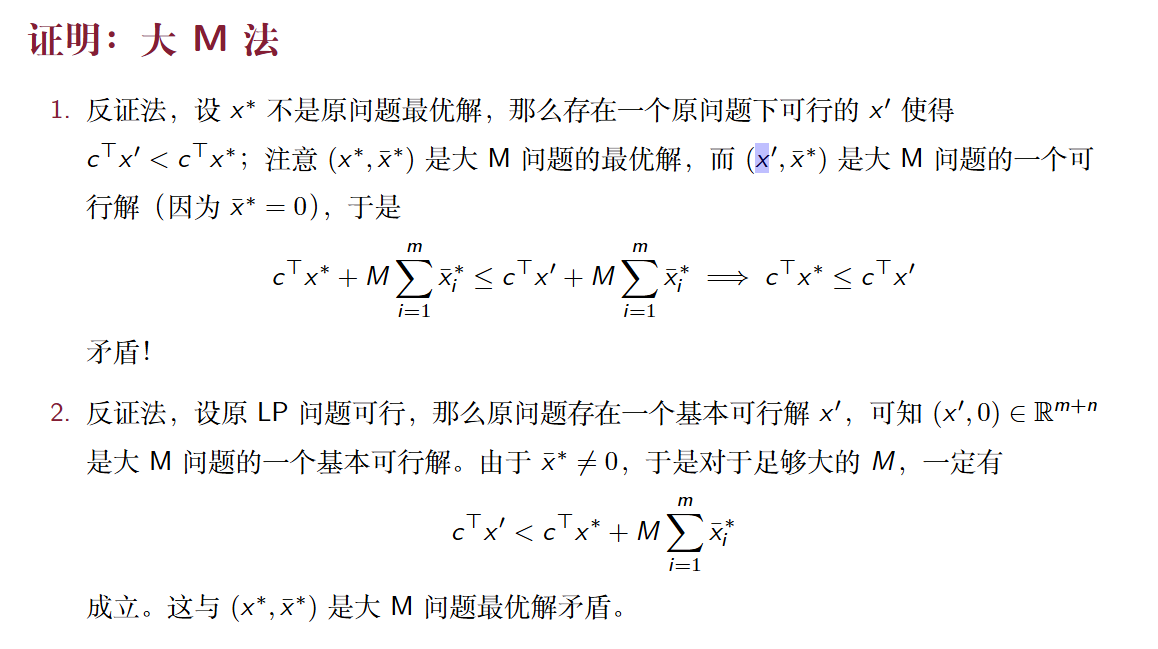

### 两阶段单纯形法

考虑：

$$
\begin{aligned}
\min \quad & \mathbf{c}^T \mathbf{x} \\
\text{s.t.} \quad & A\mathbf{x} = \mathbf{b} \\
& \mathbf{x} \geq 0
\end{aligned}
$$

不失一般性，可以假设 $\mathbf{b} \geq 0$（如果为负，则将对应的约束不等式乘以 $-1$）

假如人工变量 $\bar{\mathbf{x}} \in \mathbb{R}^m_+$，求解一个辅助问题($\mathbf{e}$ 表示全为 1 的向量)：

$$
\begin{aligned}
\min \quad & \mathbf{e}^T \bar{\mathbf{x}} \\
\text{s.t.} \quad & A\mathbf{x} + \bar{\mathbf{x}} = \mathbf{b} \\
& \mathbf{x}, \bar{\mathbf{x}} \geq 0
\end{aligned}
$$

对于该问题，$\mathbf{x} = \mathbf{0}$ 时，$\bar{\mathbf{x}} = \mathbf{b}$ 是一个基本可行解，单纯形法求解之，并称之为步骤一

> 原问题可行，当且仅当辅助问题的最优值为 $0$。

#### 证明

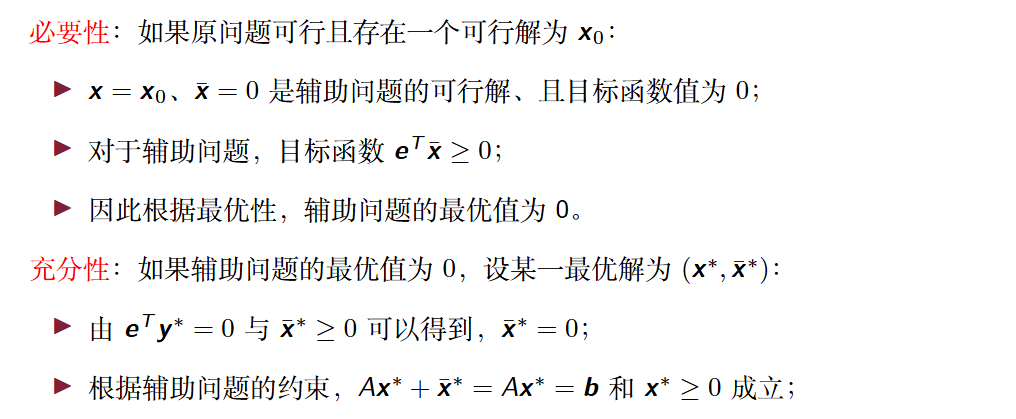

#### 两阶段法流程

阶段一：

1. 构建一个满足 $\mathbf{b} \geq 0$ 的辅助问题
2. 使用单纯形法求解辅助问题：
- 如果最优值不为 $0$，则原问题不可行
- 如果最优值为 $0$，相应的最优解为 $(\mathbf{x}^*, \mathbf{0})$，进入第二阶段

阶段二：

从基本可行解 $\mathbf{x}^*$ 开始，求解原问题

- 如果 $\mathbf{x}^*$ 是退化解，那么需要加入合适的非基变量，作为原问题基本可行解的基变量。

### 退化形

某些基变量取值为 $0$ 时，对应的基本可行解 $\mathbf{x}$ 是退化的。

- 该条件等价于，基本解中非零元素个数严格小于 $m$。
- 对于退化形问题，如果让一个取值为 $0$ 的基变量出基，则目标函数值不会发生任何改变。

通常对于 $k$ 维空间的退化点，有多于 $k$ 个超平面相交于该点。在二维空间中，退化解位于三条及三条以上的线的交点。在三维空间中，退化解存在于四个或四个以上平面的交。

由于退化问题目标函数值未严格下降，因而循环常伴随退化发生。

#### 布兰德法则

- 在所有 $\bar{c}_j < 0$ 的变量中，选择下标最小的变量作为入基变量。
- 在所有出基变量中，选择下标最小的变量作为出基变量。

布兰德法则保证单纯形法不会出现循环现象。